In [156]:
!pip install keras_tuner

     ---------------------------------------- 0.0/129.1 kB ? eta -:--:--
     --------------------------------- ---- 112.6/129.1 kB 3.3 MB/s eta 0:00:01
     -------------------------------------- 129.1/129.1 kB 2.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [157]:
import pandas as pd
import re
import spacy
import numpy as np
import matplotlib.pyplot as plt
import gensim.downloader as api
from sklearn.utils import class_weight
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Sequential
from keras.layers import Embedding, Dense, Dropout, Flatten, Bidirectional
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.layers import SimpleRNN, LSTM
from sklearn.metrics import classification_report
import keras_tuner as kt

In [2]:
# Load the pre-trained Word2Vec model (e.g., Google News)
word2vec_model = api.load("word2vec-google-news-300")

# Load SpaCy's English tokenizer
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Load the data from the CSV file
file_path = 'data/data.csv'  
# Load the data to a df using pandas
df = pd.read_csv(file_path)
# Display the first few rows to check the data
df.head()

                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


In [5]:
# Step 1: Pre-processing
# (1) Handling numerical values
def extract_numbers_with_positions(sentence):
    # Regular expression to match numbers (including decimals)
    number_pattern = r'\d+(\.\d+)?'
    
    # Create a dictionary to store numbers and their positions
    number_positions = {}
    
    # Use re.finditer to get both the number and its position (start and end)
    for match in re.finditer(number_pattern, sentence):
        number = match.group()  # The matched number
        start_pos = match.start()  # Start index of the number
        end_pos = match.end()  # End index of the number
        
        # Add the number and its position to the dictionary
        number_positions[number] = (start_pos, end_pos)
        
    sorted_number_positions = dict(sorted(number_positions.items(), key=lambda x: float(x[0])))
    
    return sorted_number_positions

def replace_keys_with_digits(sorted_number_positions):
    # Define the digits we will cycle through
    digits = ['1', '2', '3', '4', '5', '6', '7', '8', '9']
    
    # Create a new dictionary with replaced keys
    replaced_dict = {}
    
    # Iterate over the sorted dictionary and replace keys with digits
    for i, (key, value) in enumerate(sorted_number_positions.items()):
        # Use modulo to cycle through the digits list
        new_key = digits[i % len(digits)]
        replaced_dict[new_key] = value
    
    return replaced_dict

def replace_numbers_in_sentence_by_position(sentence, replaced_dict):
    # Convert the sentence to a list of characters (strings are immutable)
    sentence_chars = list(sentence)
    
    # Sort positions in reverse order to avoid shifting indices during replacement
    for digit, (start_pos, end_pos) in sorted(replaced_dict.items(), key=lambda x: x[1][0], reverse=True):
        # Replace the substring in the sentence with the new digit
        sentence_chars[start_pos:end_pos] = digit
    
    # Join the list back into a string
    return ''.join(sentence_chars)

def replace_currency_symbols(sentence):
    # Define a mapping of currency symbols to their corresponding currency names
    currency_map = {
        '$': 'USD',
        '€': 'EUR',
        '£': 'GBP',
        '¥': 'JPY',
        '₹': 'INR',
        '₩': 'KRW',
        '₽': 'RUB',
        '฿': 'THB',
        '₫': 'VND'
    }
    
    # Escape symbols for regex pattern and construct the pattern
    pattern = re.compile("|".join(re.escape(symbol) for symbol in currency_map.keys()))
    
    # Replace symbols with their corresponding currency names
    result = pattern.sub(lambda match: currency_map[match.group(0)], sentence)
    
    return result

def convert_financial_terms(sentence):
    # Define a regex pattern to match monetary values with k/m/b/t and currency symbols
    pattern = r'(\b[A-Z]{3}\s?\d+(\.\d+)?[kmbtKMBT]|\d+(\.\d+)?[kmbtKMBT]\s?[A-Z]{3})'
    
    # Dictionary to map the financial suffixes to their full terms
    suffix_map = {'k': 'thousand', 'm': 'million', 'b': 'billion', 't': 'trillion'}
    
    def replace_match(match):
        # Extract the matched string
        term = match.group(0)
        
        # Check if the currency code is at the beginning or the end
        if re.match(r'[A-Z]{3}', term[:3]):  # Currency code is at the beginning
            currency = term[:3]  # First 3 characters
            amount_with_suffix = term[3:].strip()  # The rest of the string (e.g., '7m')
        else:  # Currency code is at the end
            amount_with_suffix = term[:-3].strip()  # The number part (e.g., '7m')
            currency = term[-3:].strip()  # The last 3 characters are the currency code (e.g., 'USD')

        # Find the number and the suffix (k, m, b, t)
        number_part = re.match(r'(\d+(\.\d+)?)', amount_with_suffix).group(0)
        suffix = amount_with_suffix[len(number_part):].lower()

        # Convert the suffix to its full term using the suffix map
        if suffix in suffix_map:
            full_term = f"{number_part} {suffix_map[suffix]} {currency}"
        else:
            full_term = term  # In case no suffix found (fallback)
        
        return full_term

    # Replace all matches in the sentence
    converted_sentence = re.sub(pattern, replace_match, sentence)
    
    return converted_sentence

def remove_special_characters(sentence):
    # Use regular expressions to remove all characters except alphanumeric and spaces
    cleaned_sentence = re.sub(r'[^a-zA-Z0-9\s]', '', sentence)
    
    return cleaned_sentence

def remove_extra_spaces(sentence):
    # Split the sentence into words and join them with a single space
    cleaned_sentence = ' '.join(sentence.split())
    return cleaned_sentence

def process_sentence(sentence):
    # Step 1: Extract numbers with positions
    numbers_with_positions = extract_numbers_with_positions(sentence)
    
    # If no numbers found, return the original sentence
    if not numbers_with_positions:
        return sentence

    # Step 2: Replace the keys with digits 1-9
    replaced_dict = replace_keys_with_digits(numbers_with_positions)

    # Step 3: Replace numbers in the sentence by their positions
    new_sentence = replace_numbers_in_sentence_by_position(sentence, replaced_dict)
    
    # Step 4: Replace currency symbols to their corresponding currency names
    # modified_sentence = replace_currency_symbols(new_sentence)
    
    # step 5: convert financial terms
    converted_sentence = convert_financial_terms(new_sentence)
    
    # step 6: Remove all special characters
    processed_sentence = remove_special_characters(converted_sentence)
    
    # step 7: Remove extra spaces
    cleaned_sentence = remove_extra_spaces(processed_sentence)
    
    return cleaned_sentence

def pre_processing(data):
    # Apply the processing function to each sentence in the 'Sentence' column
    data['Processed_Sentence'] = data['Sentence'].apply(process_sentence)
    
    return data

In [13]:
# Pre-Processing
df_cleaned = pre_processing(df)

In [12]:
df_cleaned['Processed_Sentence'][2]

'For the last quarter of 4 Componenta s net sales doubled to 3 million EUR from 2 million EUR for the same period a year earlier while it moved to a zero pretax profit from a pretax loss of 1 million EUR'

In [147]:
# Create a vocabulary from the dataset
def create_vocabulary(sentences):
    vocab = {'</s>': 0}  # Start with the sentence separator token
    index = 1  # Start indexing from 1
    for sentence in sentences:
        # Tokenize using SpaCy
        doc = nlp(sentence)
        for token in doc:
            # Only include words that are in the Word2Vec model
            if token.text in word2vec_model.key_to_index and token.text not in vocab:
                vocab[token.text] = index
                index += 1
    return vocab

# Create aembedding matrix
def cal_embedding_matrix(data):
    vocabulary = create_vocabulary(data['Processed_Sentence'].tolist())
    # print("Vocabulary:", vocabulary)

    # Create the embedding matrix
    embedding_matrix = np.zeros((len(vocabulary), word2vec_model.vector_size))

    for word, index in vocabulary.items():
        if word in word2vec_model.key_to_index:
            embedding_matrix[index] = word2vec_model[word]

    # Check the size of the embedding matrix
    print("Embedding matrix shape:", embedding_matrix.shape)
    
    return embedding_matrix, vocabulary

# Function to keep tokens that are only part of vocabulary
def remove_unknown_words_from_sentence(sentence, vocab):
    doc = nlp(sentence)
    return " ".join([token.text for token in doc if token.text in vocab.keys()])

def sentences_to_vectors(sentences, vocab):
    vectors = []
    for sentence in sentences:
        sentence = remove_unknown_words_from_sentence(sentence, vocab)
        # Tokenize using SpaCy
        doc = nlp(sentence)
        # for token in doc:
            # print(token)
        vector = [vocab.get(token.text, (len(vocab)-1)) for token in doc]  # Default to vocab if token not in vocab
        vectors.append(vector)
    return vectors

def input_vectors(data, vocabulary):
    # Step 1: Convert sentences to vectors
    vectors = sentences_to_vectors(data['Processed_Sentence'].tolist(), vocabulary)
    # Step 2: Determine the maximum length
    max_length = max(len(vector) for vector in vectors)
    print(max_length)
    sequence_length = max_length + 2  # Add 1(first token (corresponding to index 0)) + 2 tokens to max length for padding
    # Step 3: Zero pad the vectors
    padded_vectors = np.array([[0] * (sequence_length - len(vector)) + vector for vector in vectors])
    
    # Output the results
    # print("Vectors:\n", vectors)
    # print("Padded Vectors:\n", padded_vectors)
    # print("Sequence Length:", sequence_length)
    
    return padded_vectors

def one_hot_encode_sentiment(df):
    # Check if 'Sentiment' column exists
    if 'Sentiment' not in df.columns:
        raise ValueError("DataFrame must contain a 'Sentiment' column.")
    
    # Step 1: Map Sentiment labels to integers
    sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
    df['Sentiment_numeric'] = df['Sentiment'].map(sentiment_mapping)
    
    # Step 2: Apply to_categorical to get one-hot vectors
    y = to_categorical(df['Sentiment_numeric'])
    
    # Step 3: Convert the result back to a DataFrame
    one_hot_df = pd.DataFrame(y, columns=['negative', 'neutral', 'positive'], index=df.index)
    
    # Step 4: Concatenate with the original DataFrame and drop 'Sentiment_numeric'
    df = pd.concat([df, one_hot_df], axis=1).drop(columns=['Sentiment_numeric'])
    
    return df

def create_input_target_and_weights(df):
    # Step 1: Create vocabulary and embedding matrix
    initial_weights, vocabulary = cal_embedding_matrix(df)  # Initial weights set as embedding matrix
    
    # Step 2: Convert sentences to vectors of embedding indices
    X = input_vectors(df, vocabulary)
    
    # Step 3: One-hot encode the sentiment labels
    df = one_hot_encode_sentiment(df)
    y = df[['negative', 'neutral', 'positive']].values  # Extract one-hot encoded columns as target
    
    return df, X, y, initial_weights, vocabulary

In [148]:
df_final, X, y, initial_weights, vocabulary = create_input_target_and_weights(df_cleaned)

Embedding matrix shape: (10977, 300)
45


In [102]:
df_final.head()

,Sentence,Sentiment,Processed_Sentence,negative,neutral,positive
0,The GeoSolutions technology will leverage Bene...,positive,The GeoSolutions technology will leverage Bene...,0.0,0.0,1.0
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,ESI on lows down 1 to 2 BK a real possibility,1.0,0.0,0.0
2,"For the last quarter of 2010 , Componenta 's n...",positive,For the last quarter of 4 Componenta s net sal...,0.0,0.0,1.0
3,According to the Finnish-Russian Chamber of Co...,neutral,According to the Finnish-Russian Chamber of Co...,0.0,1.0,0.0
4,The Swedish buyout firm has sold its remaining...,neutral,The Swedish buyout firm has sold its remaining...,0.0,1.0,0.0


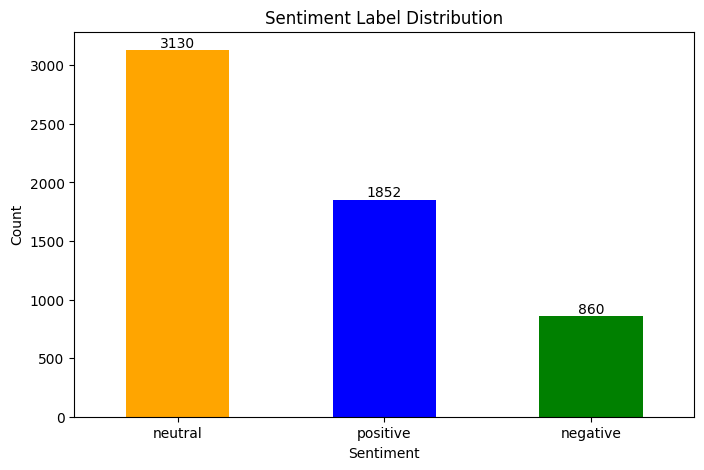

In [103]:
# Check the distribution of the sentiment labels
sentiment_counts = df_final['Sentiment'].value_counts()

# Plot the histogram
plt.figure(figsize=(8, 5))
bars = sentiment_counts.plot(kind='bar', color=['orange', 'blue', 'green'])

# Add counts on top of the bars
for bar in bars.patches:
    bars.annotate(str(bar.get_height()), 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                  ha='center', va='bottom')

plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [104]:
# sentiment mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
class_labels = df['Sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2}).values
class_weights = compute_class_weight('balanced', classes=[0, 1, 2], y=class_labels)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class Weights:", class_weights_dict)

Class Weights: {0: 2.264341085271318, 1: 0.6221512247071352, 2: 1.0514758819294456}


In [105]:
# Train and test data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
vocab_size = initial_weights.shape[0] 
embedding_dim = initial_weights.shape[1]
max_length = X.shape[1]

# # Step 1: Check initial_weights shape
# print("Initial weights shape:", initial_weights.shape)  # Should be (10977, 300)

# # Step 2: Add padding vector
# padding_vector = np.zeros((1, embedding_dim))  # Create padding token vector
# initial_weights = np.vstack([padding_vector, initial_weights])  # Add padding to the initial weights

# # Step 3: Update vocab_size
# vocab_size = initial_weights.shape[0]  # Now it should be 10978

print(vocab_size)
print(embedding_dim)
print(max_length)

10977
300
47


In [110]:
# Custom metric for Precision
def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision_value = true_positives / (predicted_positives + K.epsilon())
    return precision_value

# Custom metric for Recall
def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall_value = true_positives / (possible_positives + K.epsilon())
    return recall_value

# Custom metric for F1 Score
def f1_score(y_true, y_pred):
    precision_value = precision(y_true, y_pred)
    recall_value = recall(y_true, y_pred)
    f1_value = 2 * (precision_value * recall_value) / (precision_value + recall_value + K.epsilon())
    return f1_value

In [160]:
# We can find best hyperparams using random search for a range of values
def build_model_task1(hp):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                        input_length=max_length, weights=[initial_weights], trainable=False))
    model.add(Flatten())
    
    # Tune the number of units in the first Dense layer
    model.add(Dense(units=hp.Int('dense_units_1', min_value=128, max_value=512, step=64), activation='relu'))
    model.add(Dropout(0.5))  # Regularization
    
    # Tune the number of units in the second Dense layer
    model.add(Dense(units=hp.Int('dense_units_2', min_value=128, max_value=512, step=64), activation='relu'))
    model.add(Dropout(0.5))  # Regularization
    
    # Tune the number of units in the third Dense layer
    model.add(Dense(units=hp.Int('dense_units_3', min_value=64, max_value=256, step=32), activation='relu'))
    model.add(Dropout(0.5))  # Regularization
    
    model.add(Dense(3, activation='softmax'))  # Output layer for 3 classes

    # Compile the model
    model.compile(loss='categorical_crossentropy', 
                  optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='LOG')), 
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model_task1,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter configurations to try
    executions_per_trial=1,
    directory='my_dir',  # Directory to save results
    project_name='intro_to_kt'
)

tuner.search(X_train, y_train, 
             epochs=50, 
             validation_data=(X_val, y_val), 
             class_weight=class_weights_dict, 
             callbacks=[early_stopping])

best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hyperparameters.values)

Reloading Tuner from my_dir\intro_to_kt\tuner0.json
{'dense_units_1': 512, 'dense_units_2': 320, 'dense_units_3': 256, 'learning_rate': 0.0003197242420112309}


In [159]:
# Create a sequential model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                    input_length=max_length, weights=[initial_weights], trainable=False))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))  # Regularization
model.add(Dense(320, activation='relu'))
model.add(Dropout(0.5))  # Regularization
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Regularization
model.add(Dense(3, activation='softmax'))  # Output layer for 3 classes

# Step 3: Compile the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Print model summary
model.summary()

# Step 4: Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Step 5: Train the model with class weights if imbalance detected
history = model.fit(X_train, y_train, epochs=50, batch_size=32, 
                    validation_data=(X_val, y_val), 
                    class_weight=class_weights_dict, 
                    callbacks=[early_stopping])


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 47, 300)           3293100   
                                                                 
 flatten_1 (Flatten)         (None, 14100)             0         
                                                                 
 dense_4 (Dense)             (None, 512)               7219712   
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                                 
 dense_5 (Dense)             (None, 320)               164160    
                                                                 
 dropout_4 (Dropout)         (None, 320)               0         
                                                                 
 dense_6 (Dense)             (None, 256)              

In [161]:
def evaluate_model_performance(model, X_val, y_val, class_names=['Negative', 'Neutral', 'Positive']):
    # Step 1: Make predictions on the validation data
    y_val_pred = model.predict(X_val)

    # Step 2: Convert predictions and true labels to class labels (from one-hot encoding)
    y_val_pred_classes = np.argmax(y_val_pred, axis=1)
    y_val_true_classes = np.argmax(y_val, axis=1)

    # Step 3: Generate the classification report
    report = classification_report(y_val_true_classes, y_val_pred_classes, target_names=class_names)

    # Step 4: Print and return the report
    print(report)
    return report


In [162]:
report1 = evaluate_model_performance(model, X_val, y_val)

37/37 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

    Negative       0.33      0.50      0.40       175
     Neutral       0.74      0.71      0.73       622
    Positive       0.60      0.49      0.54       372

    accuracy                           0.61      1169
   macro avg       0.56      0.57      0.56      1169
weighted avg       0.63      0.61      0.62      1169



In [166]:
# Create a sequential model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                    input_length=max_length, weights=[initial_weights], trainable=True))  # Allow training
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))  # Regularization
model.add(Dense(320, activation='relu'))
model.add(Dropout(0.5))  # Regularization
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Regularization
model.add(Dense(3, activation='softmax'))  # Output layer for 3 classes

# Compile the model with the custom metrics
model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(learning_rate=0.001), 
              metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with class weights if imbalance detected
history = model.fit(X_train, y_train, epochs=50, batch_size=32, 
                    validation_data=(X_val, y_val), 
                    class_weight=class_weights_dict, 
                    callbacks=[early_stopping])

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 47, 300)           3293100   
                                                                 
 flatten_3 (Flatten)         (None, 14100)             0         
                                                                 
 dense_12 (Dense)            (None, 512)               7219712   
                                                                 
 dropout_9 (Dropout)         (None, 512)               0         
                                                                 
 dense_13 (Dense)            (None, 320)               164160    
                                                                 
 dropout_10 (Dropout)        (None, 320)               0         
                                                                 
 dense_14 (Dense)            (None, 256)              

In [167]:
report2 = evaluate_model_performance(model, X_val, y_val)

37/37 [==============================] - 0s 9ms/step
              precision    recall  f1-score   support

    Negative       0.34      0.55      0.42       175
     Neutral       0.83      0.63      0.72       622
    Positive       0.61      0.68      0.64       372

    accuracy                           0.64      1169
   macro avg       0.60      0.62      0.60      1169
weighted avg       0.69      0.64      0.65      1169



In [169]:
# def build_model_task3(hp):
#     model = Sequential()
    
#     # Add the Embedding layer
#     model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
#                         input_length=max_length, weights=[initial_weights], trainable=True))

#     # Tune the number of RNN layers
#     num_rnn_layers = hp.Int('num_rnn_layers', min_value=2, max_value=4, step=1)
    
#     # Add stacked RNN layers
#     for _ in range(num_rnn_layers):
#         # Tune the number of neurons in each RNN layer
#         rnn_neurons = hp.Int('rnn_neurons', min_value=64, max_value=512, step=64)
#         model.add(SimpleRNN(units=rnn_neurons, return_sequences=True))

#     # Flatten the output before the dense layers
#     model.add(Flatten())
    
#     # Tune dense layer neurons
#     dense_neurons = hp.Int('dense_neurons', min_value=64, max_value=256, step=64)
    
#     # Classification head
#     model.add(Dense(dense_neurons, activation='relu'))
#     model.add(Dropout(0.5))  # Regularization
#     model.add(Dense(64, activation='relu'))
#     model.add(Dropout(0.5))  # Regularization
#     model.add(Dense(3, activation='softmax'))  # Output layer for 3 classes

#     # Tune the learning rate
#     learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG', default=1e-3)
    
#     # Compile the model
#     model.compile(loss='categorical_crossentropy', 
#                   optimizer=Adam(learning_rate=learning_rate), 
#                   metrics=['accuracy'])
    
#     return model

# # Initialize the tuner
# tuner = kt.RandomSearch(
#     build_model_task3,
#     objective='val_accuracy',  # Can also use 'val_loss'
#     max_trials=10,  # Number of different hyperparameter combinations to try
#     executions_per_trial=1,
#     directory='hyperparameter_tuning',
#     project_name='rnn_tuning'
# )

# # Step 4: Search for the best hyperparameters
# tuner.search(X_train, y_train, 
#              epochs=50, 
#              batch_size=32, 
#              validation_data=(X_val, y_val), 
#              class_weight=class_weights_dict, 
#              callbacks=[early_stopping])

# # Step 5: Get the best model
# best_model = tuner.get_best_models(num_models=1)[0]

# # Print the best hyperparameters
# best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("Best Hyperparameters:")
# print(f"Num RNN Layers: {best_hyperparameters.get('num_rnn_layers')}")
# print(f"RNN Neurons: {best_hyperparameters.get('rnn_neurons')}")
# print(f"Dense Neurons: {best_hyperparameters.get('dense_neurons')}")
# print(f"Learning Rate: {best_hyperparameters.get('learning_rate')}")

# Reloading Tuner from my_dir\intro_to_kt\tuner0.json
# {'num_rnn_layers': 2, 'rnn_neurons': 384, 'dense_neurons': 192, 'learning_rate': 0.00025666}

In [176]:
def create_rnn_model(vocab_size, embedding_dim, initial_weights, max_length, num_rnn_layers=2):
    model = Sequential()
    
    # Add the Embedding layer
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                        input_length=max_length, weights=[initial_weights], trainable=True))

    # Add stacked RNN layers
    for _ in range(num_rnn_layers):
        model.add(LSTM(128, return_sequences=True))  # Using LSTM; change to SimpleRNN if needed

    # Flatten the output before the dense layers
    model.add(Flatten())
    
    # # Classification head
    # model.add(Dense(192, activation='relu'))
    # model.add(Dropout(0.5))  # Regularization
    # model.add(Dense(64, activation='relu'))
    # model.add(Dropout(0.5))  # Regularization
    model.add(Dense(3, activation='softmax'))  # Output layer for 3 classes
    
    # Compile the model
    model.compile(loss='categorical_crossentropy', 
                  optimizer=Adam(learning_rate=0.001), 
                  metrics=['accuracy'])
    
    return model

# Create and compile the model
model = create_rnn_model(vocab_size, embedding_dim, initial_weights, max_length, num_rnn_layers=2)  # Try 2-4 layers

# Print model summary
model.summary()

# Set up early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with class weights if imbalance detected
history = model.fit(X_train, y_train, epochs=50, batch_size=32, 
                    validation_data=(X_val, y_val), 
                    class_weight=class_weights_dict, 
                    callbacks=[early_stopping])

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 47, 300)           3293100   
                                                                 
 lstm_6 (LSTM)               (None, 47, 128)           219648    
                                                                 
 lstm_7 (LSTM)               (None, 47, 128)           131584    
                                                                 
 flatten_5 (Flatten)         (None, 6016)              0         
                                                                 
 dense_13 (Dense)            (None, 3)                 18051     
                                                                 
Total params: 3,662,383
Trainable params: 3,662,383
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
147/147 [========================

In [177]:
report3 = evaluate_model_performance(model, X_val, y_val)

37/37 [==============================] - 2s 31ms/step
              precision    recall  f1-score   support

    Negative       0.42      0.63      0.50       175
     Neutral       0.83      0.70      0.76       622
    Positive       0.72      0.73      0.73       372

    accuracy                           0.70      1169
   macro avg       0.65      0.69      0.66      1169
weighted avg       0.73      0.70      0.71      1169



In [173]:
def complex_bidirectional_rnn_classifier(vocab_size, embedding_dim, max_length, initial_weights):
    # Initialize the sequential model
    model = Sequential()

    # Embedding layer with pre-trained weights
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                        input_length=max_length, weights=[initial_weights], trainable=False))

    # Add stacked bidirectional RNN layers
    model.add(Bidirectional(LSTM(128, return_sequences=True)))  # First bidirectional RNN
    model.add(Dropout(0.3))  # Regularization
    model.add(Bidirectional(LSTM(32, return_sequences=True)))  # Second bidirectional RNN
    model.add(Dropout(0.3))

    # Flatten before passing to the classifier head
    model.add(Flatten())

    # Classification head
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))  # Output layer for 3 classes

    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

    # Print the model summary
    model.summary()

    return model

# Create model instance
model = complex_bidirectional_rnn_classifier(vocab_size=vocab_size, embedding_dim=embedding_dim, 
                                             max_length=max_length, initial_weights=initial_weights)

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, 
                    validation_data=(X_val, y_val), 
                    class_weight=class_weights_dict, 
                    callbacks=[early_stopping])

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 47, 300)           3293100   
                                                                 
 bidirectional (Bidirectiona  (None, 47, 256)          439296    
 l)                                                              
                                                                 
 dropout_6 (Dropout)         (None, 47, 256)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 47, 64)           73984     
 nal)                                                            
                                                                 
 dropout_7 (Dropout)         (None, 47, 64)            0         
                                                                 
 flatten_3 (Flatten)         (None, 3008)             

In [174]:
report4 = evaluate_model_performance(model, X_val, y_val)

37/37 [==============================] - 3s 50ms/step
              precision    recall  f1-score   support

    Negative       0.48      0.81      0.60       175
     Neutral       0.85      0.76      0.80       622
    Positive       0.83      0.70      0.76       372

    accuracy                           0.75      1169
   macro avg       0.72      0.76      0.72      1169
weighted avg       0.79      0.75      0.76      1169



In [151]:
# Dictionary to store words that appear in different cases
repeated_words = {}

# Check for words with different cases
for word in vocabulary:
    lowercase_word = word.lower()
    if lowercase_word not in repeated_words:
        repeated_words[lowercase_word] = []
    repeated_words[lowercase_word].append(word)

# Filter to keep only entries where multiple cases are present
repeated_words_with_cases = {k: v for k, v in repeated_words.items() if len(v) > 1}

# Display first 10 words with different cases
for i, (word, cases) in enumerate(repeated_words_with_cases.items()):
    if i >= 10:
        break
    print(f"{word}: {cases}")

the: ['The', 'the', 'THE']
technology: ['technology', 'Technology']
will: ['will', 'Will']
solutions: ['solutions', 'Solutions']
by: ['by', 'BY', 'By']
location: ['Location', 'location']
based: ['Based', 'based']
search: ['Search', 'search']
communities: ['Communities', 'communities']
platform: ['Platform', 'platform']


In [154]:
from scipy.spatial.distance import cosine

# Example words to check
words = ['The', 'the', 'THE']
# words = ['technology', 'Technology']


# Retrieve embeddings for each word
embeddings = {word: word2vec_model[word] for word in words if word in word2vec_model}

# Calculate pairwise cosine similarity
similarities = {}
for i, word1 in enumerate(words):
    for j, word2 in enumerate(words):
        if i < j:
            if word1 in embeddings and word2 in embeddings:
                similarity = 1 - cosine(embeddings[word1], embeddings[word2])
                similarities[(word1, word2)] = similarity
            else:
                similarities[(word1, word2)] = "Embedding not found."

# Display similarities
for pair, similarity in similarities.items():
    print(f"Similarity between '{pair[0]}' and '{pair[1]}': {similarity}")


Similarity between 'The' and 'the': 0.4476718604564667
Similarity between 'The' and 'THE': 0.43926674127578735
Similarity between 'the' and 'THE': 0.21784256398677826
